# Test of apex detection methodology by Limaye (2025)
This notebooks aims at testing the methodology of apex detection by Limaye (2025) on synthetic bends. 

Synthetic bends are creatd from parameteric curves:
        
* Circular bend: $\begin{cases}\begin{align*} &x(s)=A.\cos(\pi s/\lambda+\pi) \\ &y(s)=A.\sin(\pi s/\lambda) \end{align*}\end{cases}$

  where $x$ and $y$ are cartesian coordinates, $s$ is the curvilinear abscissa, $A$ is bend amplitude, and $\lambda$ is bend arc length.
* Kinoshita bend (Kinoshita, 1961): $\begin{cases}\begin{align*} &\Theta(s)=\Theta_0.\cos\left(\frac{2\pi s}{\lambda}\right)+\Theta_0^3\left(Js.\sin\left(3\frac{2\pi s}{\lambda}\right)-Jf.\cos\left(3\frac{2\pi s}{\lambda}\right)\right) \\ &x(s+ds)=x(s)+ds*\cos(\Theta) \\ &y(s+ds)=y(s)+ds*\sin(\Theta) \end{align*}\end{cases}$

  where $\Theta$ and $\Theta_0$ are the angle and maximum angle, $Js$ is the skewness coefficient, $Jf$ is the flatness coefficient, and $ds$ the distance between two consecutive points.

### References
- Kinoshita, R. (1961), Investigation of channel deformation in Ishikari River, Publ., vol. 36, p. 139, Nat. Resour. Div., Minist. of Sci. and Technol. of Jpn, Tokyo
- Limaye (2025) *A geometric algorithm to identify river meander bends: 1. Effect of perspective.* Journal of Geophysical Research: Earth Surface, 130, e2024JF007908. https://doi.org/10.1029/2024JF007908

In [44]:
# import modules and load data
import os
import sys

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from scipy.signal import find_peaks

# output directory for figures
fig_path = str(os.path.join(os.getcwd(), ".outputs/"))
# create it if absent
if not os.path.exists(fig_path):
   os.makedirs(fig_path)

def compute_curvature(x, y):
    """Compute curvature of curve defined by coordinates x and y

    Modified from https://github.com/zsylvester/curvaturepy/blob/master/cline_analysis.py 
    """
    dx = np.gradient(x); dy = np.gradient(y)  # first derivatives    
    ds = np.sqrt(dx**2+dy**2)
    ddx = np.gradient(dx); ddy = np.gradient(dy) # second derivatives 
    curvature = (dx*ddy - dy*ddx) / ((dx**2 + dy**2)**1.5) # curvature
    return curvature
    
def circular_bend(nb_pts: int) -> npt.NDArray[np.float64]:
    """Create a circular bend.

    Args:
        nb_pts (int): number of points along bend centerline

    Returns:
        npt.NDArray[np.float64]: point coordinates

    """
    coords_x: list[float] = []
    coords_y: list[float] = []
    i: int = 0
    while i < nb_pts:
        t: float = np.pi * i / (nb_pts - 1)
        coords_x += [np.cos(t + np.pi)]
        coords_y += [np.sin(t)]
        i += 1

    coords: npt.NDArray[np.float64] = np.column_stack((coords_x, coords_y))
    return coords
    
def kinoshita_bend(
    nb_pts: int, teta_max: float, Js: float, Jf: float
) -> npt.NDArray[np.float64]:
    r"""Create a Kinoshita bend.

    Bend centerline follows the Kinoshita curve (Kinoshita, 1961):

    .. math::
        $\Theta=\Theta_0.\cos(\frac{2\pi.s}{\lambda})+\Theta_0^3.(Js.\sin(3\frac{2\pi.s}{\lambda})-Jf.\cos(3\frac{2\pi.s}{\lambda}))$

    where :math:`$\Theta$` is the local angle from x axis, :math:`$\Theta_0$`
    the maximum angle, :math:`$s$` the curvilinear coordinate,
    :math:`$\lambda$` the wavelength, :math:`$Js$` the skewness coefficient,
    and :math:`$Jf$` the flattening coefficient.

    Inflection point may be downstream the first point at
    :math:`$\Theta=\Theta_0$`, then the bend between inflection points is
    determined from:

        1. compute point coordinates over a bit more than a wavelength,
        2. find inflection points
        3. return coords in-between inflection points

    Args:
        nb_pts (int): number of points along bend centerline
        teta_max (float): maximum angle (rad) from horizontal axis
        Js (float): skewness coefficient. If positive, bends are left skewed,
            if negative bends are right skewed.
        Jf (float): flatness coefficient. If positive, bends are more
            elongated, if negative bends are more flat.

    Returns:
        npt.NDArray[np.float64]: point coordinates

    """
    coords_x: list[float] = [0.0]
    coords_y: list[float] = [0.0]
    teta: float = teta_max
    ds: float = 1.0
    for i in range(int(round(1.3 * nb_pts))):
        i1 = i - (nb_pts / 6)
        t: float = np.pi * i1 / (nb_pts - 1)
        teta = teta_max * np.cos(t) + teta_max**3 * (
            Js * np.sin(3 * t) - Jf * np.cos(3 * t)
        )
        coords_x += [coords_x[i] + ds * np.cos(teta)]
        coords_y += [coords_y[i] + ds * np.sin(teta)]

    # remove first point that may not be accurate
    coords_x = coords_x[1:]
    coords_y = coords_y[1:]

    # get coords of the bend where curvature is negative
    curvature: npt.NDArray[np.float64] = compute_curvature(coords_x, coords_y)
    coords: npt.NDArray[np.float64] = np.column_stack((coords_x, coords_y))
    coords1 = coords[np.nonzero(curvature <= 0)]

    # normalize bend x coordinates between 0 and 1
    xmin = np.min(coords1[:, 0])
    xmax = np.max(coords1[:, 0])
    coords1 = (coords1 - xmin) / (xmax - xmin)

    # return coordinates between inflection points
    return coords1

# Create analytic meander bend shape   
nb_pts = 101

# circular bend
C0 = circular_bend(nb_pts)

# kinoshita meander bends
Js = 0.
Jf = 0.

# K1: teta0=50°, Js=0, Jf=0
# K2: teta0=115°, Js=0, Jf=0
# K3: teta0=110°, Js=0., Jf=-0.06
# K4: teta0=110°, Js=0.01, Jf=0.03
# K5: teta0=90°, Js=0.02, Jf=-0.04
# K6: teta0=110°, Js=0.03, Jf=0
# K7: teta0=110°, Js=0.03, Jf=-0.03
# K8: teta0=110°, Js=0.03, Jf=-0.06
teta_max = 100. * np.pi / 180.
K1 = kinoshita_bend(nb_pts, teta_max, Js, Jf)

# K2: teta0=115°, Js=0, Jf=0
teta_max = 125. * np.pi / 180.
K2 = kinoshita_bend(nb_pts, teta_max, Js, Jf)

# K3: teta0=110°, Js=0., Jf=-0.06
teta_max = 110. * np.pi / 180.
Js = 0.0
Jf = -0.06
K3 = kinoshita_bend(nb_pts, teta_max, Js, Jf)

# K4: teta0=110°, Js=0.01, Jf=0.03
teta_max = 110. * np.pi / 180.
Js = 0.01
Jf = 0.03
K40 = kinoshita_bend(nb_pts, teta_max, Js, Jf)
K41 = kinoshita_bend(nb_pts, teta_max, -1*Js, Jf)

# K5: teta0=90°, Js=0.02, Jf=-0.04
teta_max = 90. * np.pi / 180.
Js = 0.02
Jf = -0.04
K50 = kinoshita_bend(nb_pts, teta_max, Js, Jf)
K51 = kinoshita_bend(nb_pts, teta_max, -1*Js, Jf)

# K6: teta0=110°, Js=0.03, Jf=0
teta_max = 110. * np.pi / 180.
Js = 0.03
Jf = 0. 
K60 = kinoshita_bend(nb_pts, teta_max, Js, Jf)
K61 = kinoshita_bend(nb_pts, teta_max, -1*Js, Jf)

# K7: teta0=110°, Js=0.03, Jf=-0.03
teta_max = 110. * np.pi / 180.
Js = 0.03
Jf = -0.03
K70 = kinoshita_bend(nb_pts, teta_max, Js, Jf)
K71 = kinoshita_bend(nb_pts, teta_max, -1*Js, Jf)

# K8: teta0=110°, Js=0.03, Jf=-0.06
teta_max = 110. * np.pi / 180.
Js = 0.03
Jf = -0.06
K80 = kinoshita_bend(nb_pts, teta_max, Js, Jf)
K81 = kinoshita_bend(nb_pts, teta_max, -1*Js, Jf)

# plot parameters
bend_coords = (C0, K1, K2, K3, K40, K41, K50, K51, K60, K61, K70, K71, K80, K81)
bend_names = ("C0", "K1", "K2", "K3", "K40", "K41", "K50", "K51", "K60", "K61", "K70", "K71", "K80", "K81")
print("Bends created")

Bends created


1.555095363233813
1.5707963267948966
1.5707963267948966
1.5707963267948966
1.5707963267948966
1.5707963267948966
1.5707963267948966
1.5707963267948966
1.5707963267948966
1.5707963267948966
1.5707963267948966
1.5707963267948966
1.5707963267948966
1.5707963267948966


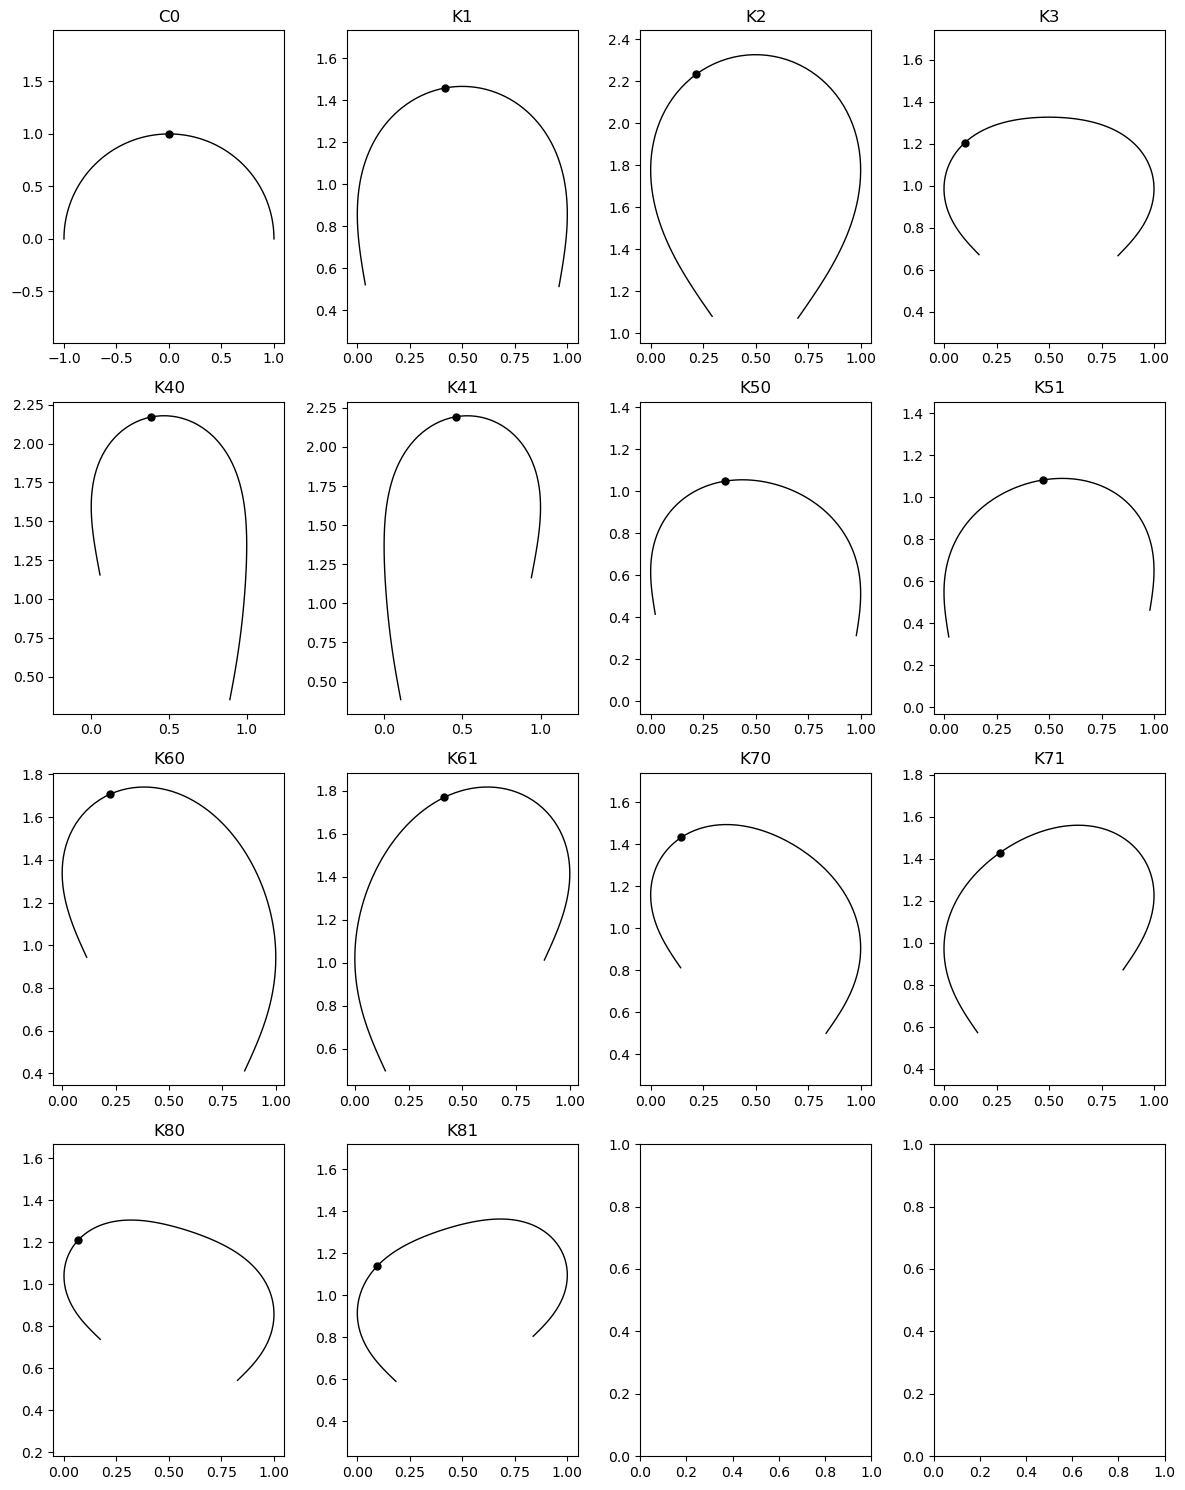

In [49]:
def get_angle_between_vectors(
    vec1: npt.NDArray[np.float64], vec2: npt.NDArray[np.float64]
) -> float:
    """Get the oriented angle between two vectors.

    Args:
        vec1 (npt.NDArray[np.float64]): first vector
        vec2 (npt.NDArray[np.float64]): second vector

    Returns:
        float: angle between the two vectors.

    """
    vec1_norm: npt.NDArray[np.float64] = vec1 / np.linalg.norm(vec1)
    vec2_norm: npt.NDArray[np.float64] = vec2 / np.linalg.norm(vec2)
    dot: float = np.dot(vec1_norm, vec2_norm)
    det: float = np.linalg.det((vec1_norm, vec2_norm))
    # round to prevent from numerical approximations
    teta: float = np.arccos(round(dot, 6))
    if det < 0:
        teta = 2.0 * np.pi - teta
    return teta


def compute_half_angle_variation(normal: npt.NDArray[np.float64]) -> int:
    """Get the index of half path angle variation.

    Args:
        normal (npt.NDArray[np.float64]): normal vectors to channel path

    Returns:
        int: index of median curvature

    """
    normal2 = np.copy(normal)
    # use first normal vector as reference direction
    ref: npt.NDArray[np.float64] = normal2[0]
    if ref[0] < 0.0:
        normal2 *= -1

    # compute angle variation of each normal vector from reference vector
    teta: npt.NDArray[np.float64] = np.zeros(normal2.shape[0])
    for i, vec in enumerate(normal2):
        teta[i] = get_angle_between_vectors(ref, vec)

    # correction of teta[0] depending on rotation direction
    teta[0] = 2.0 * np.pi if teta[1] > np.pi else 0.0

    # if angle decreases from first to last point, use the complementary angle
    if (teta[-1] - teta[0]) < 0:
        teta = 2 * np.pi - teta

    # get the total angle variation from first to last point
    d_teta: float = teta[-1] - teta[0]
    # compute angle at apex
    index = 0
    teta_apex: float = teta[0]
    #teta_apex += d_teta / 2.0
    if d_teta <= np.pi:
        teta_apex += d_teta / 2.0
    else:
        teta_apex += np.pi / 2.0
    
    # find the index of the apex
    print(teta_apex)
    try:
        index = int(np.nonzero(teta >= teta_apex)[0][0])
    except IndexError:
        print("Error: teta_apex not found")

    return index

def normal(vec: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
    """Compute the normalized orthogonal vector to input.

    Args:
        vec (NDArray[float]): Coordinates of the vector.

    Returns:
        NDArray[float]: Coordinates of the normalized orthogonal vector.

    """
    # get clockwise orthogonal vector
    normal_vec: npt.NDArray[np.float64] = np.zeros_like(vec)
    normal_vec[0], normal_vec[1] = -vec[1], vec[0]
    # noramlize vector
    normal_vec /= np.linalg.norm(normal_vec)
    return normal_vec
    
def find_apex_Limaye(bend: npt.NDArray[np.float64]) ->int:
    """Compute apex index according to Limaye (2025) methodology.

    Args:
        bend (2DArray[np.float64]): channel point coordinates.
    
    Returns:
        npt.NDArray[np.int64]: inflection point indices
    """
    # compute normal vector to centerline
    ln: npt.NDArray[np.float64] = np.zeros_like(bend)

    # compute traject vector
    for j, pt in enumerate(bend):
        if j < bend.shape[0] - 1:
            pt0 = pt
            pt1 = bend[j + 1]
        else:
            pt0 = bend[j - 1]
            pt1 = pt
        ln[j] = pt1 - pt0

     # compute normal vector instead of traject vector
#    for j, pt in enumerate(bend):
#        if j == 0:
#            pt0 = pt
#            pt1 = bend[j + 1]
#        elif j == bend.shape[0] - 1:
#            pt0 = bend[j - 1]
#            pt1 = pt
#        else:
#            pt0 = bend[j - 1]
#            pt1 = bend[j + 1]
#        ln[j] = normal(pt0 - pt1)
    # compute apex index
    return compute_half_angle_variation(ln)
    
fig, axes = plt.subplots(4, 4, figsize=(12, 15))
for i, (bend, name, ax) in enumerate(zip(bend_coords, bend_names, axes.flatten())):
    ax.plot(bend[:,0], bend[:,1], 'k-', linewidth=1)

    apex_index = find_apex_Limaye(bend)
    ax.plot(bend[apex_index][0], bend[apex_index][1], 'ko', markersize=5)
    ax.set_title(name)
    
    ax.axis('equal')
plt.tight_layout()
plt.show()    